<h4 align="center"><i>In the name of Allah, the Most Gracious, the Most Merciful</i></h4>

# 🎓 Project Title: **Medical Insurance Cost**

📋 Statistical Summary of the Dataset:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


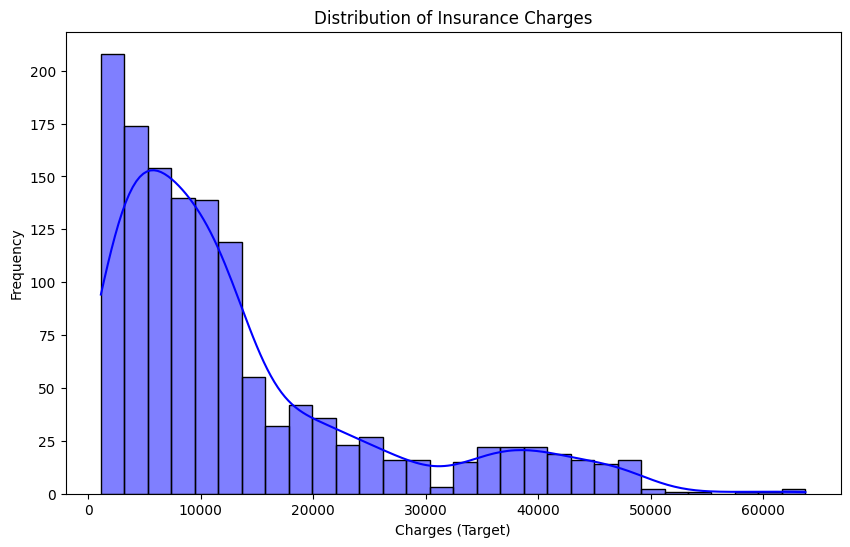

C:\Users\hp\AppData\Local\Temp\ipykernel_15936\2598531261.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


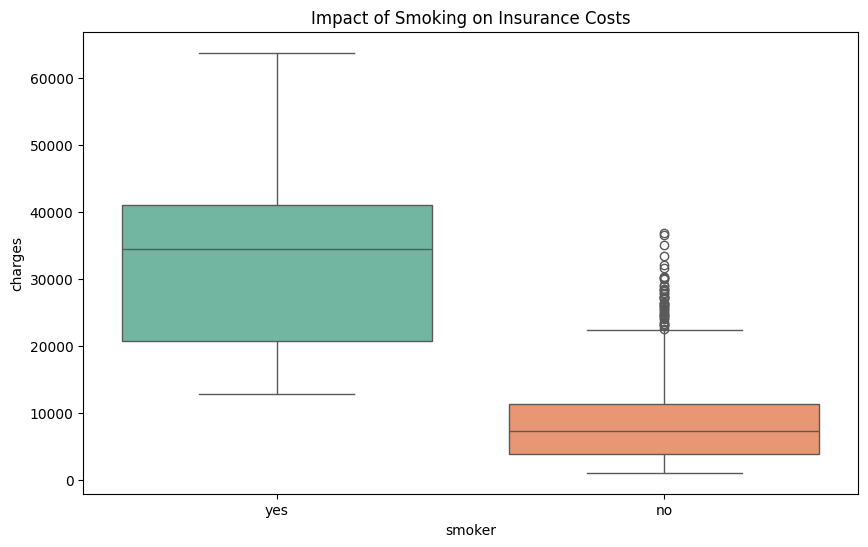

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('data/insurance (1).csv')

# --- 1. Statistical Overview ---
# This step gives us a mathematical summary of all numerical columns (age, bmi, children, charges)
print("📋 Statistical Summary of the Dataset:")
display(df.describe())

# --- 2. Target Variable Distribution (Charges) ---
# We visualize how the insurance prices are spread out across the dataset
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges (Target)')
plt.ylabel('Frequency')
plt.show()

# --- 3. Relationship: Smoking vs. Charges ---
# Since smoking is a categorical feature, a Boxplot is the best way to see how it affects the numerical price
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Impact of Smoking on Insurance Costs')
plt.show()

In [53]:
# 1. Convert Categorical columns to Numerical
# For Smoker and Sex (Binary: 0 or 1)
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'female': 1, 'male': 0})

# For Region (More than 2 categories) - use One-Hot Encoding
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# 2. Split Data into X (Features) and y (Target)
X = df.drop('charges', axis=1)
y = df['charges']

# 3. Train-Test Split (80% Training, 20% Testing)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Preprocessing Complete!")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
display(X_train.head())

✅ Preprocessing Complete!
Training features shape: (1070, 8)
Testing features shape: (268, 8)


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
560,46,1,19.95,2,0,True,False,False
1285,47,1,24.32,0,0,False,False,False
1142,52,1,24.86,0,0,False,True,False
969,39,1,34.32,5,0,False,True,False
486,54,1,21.47,3,0,True,False,False


In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize the Linear Regression model
lr_model = LinearRegression()

# 2. Train the model using the training data
lr_model.fit(X_train, y_train)

# 3. Make predictions on the test data
y_pred = lr_model.predict(X_test)

# 4. Evaluate the model performance
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5 # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print("🎯 First Model: Linear Regression")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# 5. Let's look at the first 5 actual vs predicted values
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(comparison_df.head())

🎯 First Model: Linear Regression
Mean Squared Error (MSE): 33596915.85
Root Mean Squared Error (RMSE): 5796.28
R² Score: 0.7836


,Actual,Predicted
764,9095.06825,8969.550274
887,5272.17580,7068.747443
890,29330.98315,36858.410912
1293,9301.89355,9454.678501
259,33750.29180,26973.173457


In [55]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model
rf_model.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf)**0.5

print("🌲 Second Model: Random Forest Regressor")
print(f"R² Score: {r2_rf:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")

# Comparison with the previous model
print(f"\n📈 Improvement in R²: {((r2_rf - r2) / r2) * 100:.2f}%")

🌲 Second Model: Random Forest Regressor
R² Score: 0.8666
Root Mean Squared Error (RMSE): 4550.74

📈 Improvement in R²: 10.59%


In [47]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameters we want to test
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# 2. Initialize Grid Search
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           cv=5, n_jobs=-1, scoring='r2')

# 3. Fit Grid Search to the data
grid_search.fit(X_train, y_train)

# 4. Get the best model
best_rf = grid_search.best_estimator_

print("⚙️ Tuning Complete!")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"New R² Score: {grid_search.best_score_:.4f}")

⚙️ Tuning Complete!
Best Parameters: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 300}
New R² Score: 0.8448


# Get feature importances



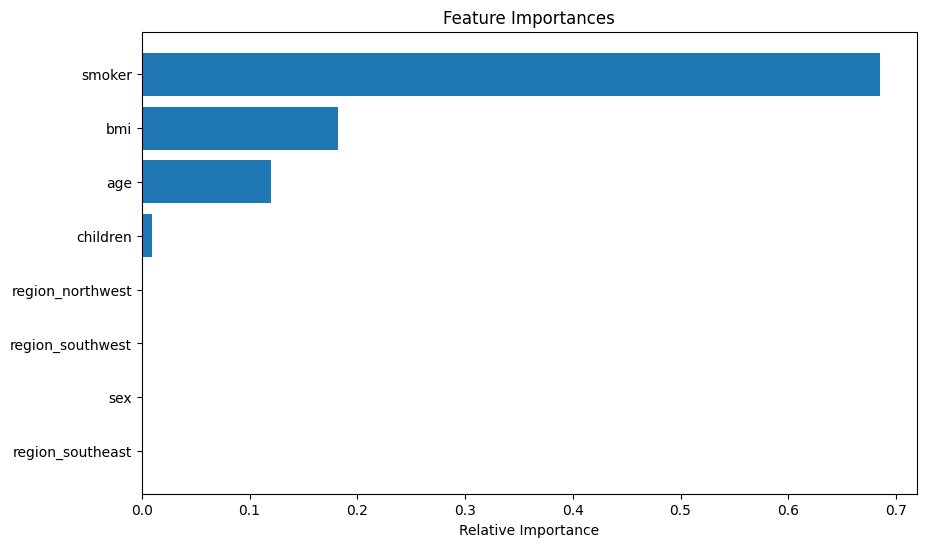

In [56]:
import numpy as np

# Get feature importances
importances = best_rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [50]:
import joblib
import os

# Create a directory for our production models
os.makedirs('production_models', exist_ok=True)

# 1. Save the trained model
joblib.dump(best_rf, 'production_models/insurance_model.pkl')

# 2. Save the column names (Crucial for the App to know the order of inputs)
model_columns = list(X.columns)
joblib.dump(model_columns, 'production_models/model_columns.pkl')

print("🚀 Model is packaged and ready for production!")

🚀 Model is packaged and ready for production!


# start from stratch with pipline


In [63]:
# إعادة تحميل البيانات لضمان أنها "خام" بدون تعديلات سابقة
df_raw = pd.read_csv('data/insurance (1).csv')

# تقسيم البيانات إلى ميزات وهدف
X = df_raw.drop('charges', axis=1)
y = df_raw['charges']

# تقسيم للتدريب واختبار (نفس النسبة السابقة)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data reloaded and ready for the Pipeline!")

✅ Data reloaded and ready for the Pipeline!


In [64]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR

# 1. تحديد الأعمدة
numeric_cols = ['age', 'bmi', 'children']
categorical_cols = ['sex', 'smoker', 'region']

# 2. بناء المعالج (Scaling للأرقام و Encoding للنصوص)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# 3. قائمة الموديلات التي سنقارن بينها
models_to_test = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=5),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100),
    'SVR': SVR(kernel='rbf', C=10000)
}

# 4. تدريب واختبار الجميع
for name, model in models_to_test.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipe.fit(X_train, y_train)
    score = pipe.score(X_test, y_test)
    print(f"📊 {name} R² Score: {score:.4f}")

📊 Linear R² Score: 0.7836
📊 Ridge R² Score: 0.7834
📊 Lasso R² Score: 0.7835
📊 Random Forest R² Score: 0.8754
📊 Gradient Boosting R² Score: 0.8787
📊 SVR R² Score: 0.8496


In [65]:
import joblib

# 1. إنشاء الـ Pipeline النهائي باستخدام أفضل موديل
final_best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100))
])

# 2. تدريب الموديل على كامل البيانات المتاحة لزيادة قوته
final_best_pipeline.fit(X, y)

# 3. حفظ الموديل الشامل
os.makedirs('production_models', exist_ok=True)
joblib.dump(final_best_pipeline, 'production_models/full_insurance_pipeline.pkl')

print("🚀 The Champion Model (Gradient Boosting) is saved and ready for the App!")

🚀 The Champion Model (Gradient Boosting) is saved and ready for the App!
